# Initialization & Data Preparation

### Set seed and load data

In [1]:
from pathlib import Path
import pandas as pd


seed = 42
candidate_paths = [Path("ticketmaster_processed_english.csv"), Path("ECE569A/Course_Project/ticketmaster_processed_english.csv")]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find ticketmaster_processed_english.csv. "
        "Run the notebook from the course-project folder or the workspace root."
    )

df = pd.read_csv(data_path)
print("Loaded:", data_path)
print("Shape:", df.shape)
df.head()


Loaded: ticketmaster_processed_english.csv
Shape: (16338, 19)


,subject,body,combined_text,type,priority,queue,language,tag_1,tag_2,answer,text_char_len,text_word_len,version,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,...",Incident,high,Technical Support,en,Account,Disruption,"Thank you for reaching out, <name>. We are awa...",563,84,51,Outage,IT,Tech Support,NaN,NaN,NaN
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...,Request,medium,Returns and Exchanges,en,Product,Feature,Thank you for your inquiry. Our products suppo...,585,83,51,Tech Support,NaN,NaN,NaN,NaN,NaN
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...,Request,low,Billing and Payments,en,Billing,Payment,We appreciate you reaching out with your billi...,639,95,51,Account,Documentation,Feedback,NaN,NaN,NaN
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Question About Marketing Agency Software Compa...,Problem,medium,Sales and Pre-Sales,en,Product,Feature,Thank you for your inquiry. Our product suppor...,732,103,51,Feedback,Tech Support,NaN,NaN,NaN,NaN
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...","Feature Query Dear Customer Support,\n\nI hope...",Request,high,Technical Support,en,Feature,Product,Thank you for your inquiry. Please specify whi...,660,99,51,Documentation,Feedback,NaN,NaN,NaN,NaN


### Extract Data to Form X and Responses y1, y2, and y3

In [2]:
X = df["combined_text"]
y1 = df["type"]
y2 = df["priority"]
y3 = df["queue"]

print("X shape:", X.shape)
print("y1 type shape:", y1.shape)
print("y2 priority shape:", y2.shape)
print("y3 queue shape:", y3.shape)


X shape: (16338,)
y1 type shape: (16338,)
y2 priority shape: (16338,)
y3 queue shape: (16338,)


### BERT Embedding Extraction

In [3]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel


bert_model_name = "distilbert-base-uncased"
device = torch.device("cpu")
tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name).to(device)
bert_model.eval()
def embed_texts(texts, tokenizer, model, device, batch_size=32, max_length=128):
    texts = list(texts)
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch = texts[start:start + batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
            outputs = model(**encoded)
            token_embeddings = outputs.last_hidden_state
            attention_mask = encoded["attention_mask"].unsqueeze(-1).float()
            summed = (token_embeddings * attention_mask).sum(dim=1)
            counts = attention_mask.sum(dim=1).clamp(min=1e-9)
            mean_pooled = summed / counts
            embeddings.append(mean_pooled.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

X_bert = embed_texts(X, tokenizer, bert_model, device)
print("BERT embedding matrix shape:", X_bert.shape)


BERT embedding matrix shape: (16338, 768)


### Stratified Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split


test_size = 0.2

X_train_y1, X_test_y1, y1_train, y1_test = train_test_split(
    X_bert, y1,
    test_size=test_size,
    random_state=seed,
    stratify=y1,
)

X_train_y2, X_test_y2, y2_train, y2_test = train_test_split(
    X_bert, y2,
    test_size=test_size,
    random_state=seed,
    stratify=y2,
)

X_train_y3, X_test_y3, y3_train, y3_test = train_test_split(
    X_bert, y3,
    test_size=test_size,
    random_state=seed,
    stratify=y3,
)

print("y1/type train-test shapes:", X_train_y1.shape, X_test_y1.shape, y1_train.shape, y1_test.shape)
print("y2/priority train-test shapes:", X_train_y2.shape, X_test_y2.shape, y2_train.shape, y2_test.shape)
print("y3/queue train-test shapes:", X_train_y3.shape, X_test_y3.shape, y3_train.shape, y3_test.shape)


y1/type train-test shapes: (13070, 768) (3268, 768) (13070,) (3268,)
y2/priority train-test shapes: (13070, 768) (3268, 768) (13070,) (3268,)
y3/queue train-test shapes: (13070, 768) (3268, 768) (13070,) (3268,)


# NN (Predicting y1, Type)

### Genetic Algorithm Tuning for Type
- Population of 8 individuals evolved over 5 generations
- Fitness selection strategy: weighted F1 score, scoring="f1_weighted"
- Use 3-fold stratified CV inside the fitness function

In [5]:
from genetic_algorithm import build_pipeline, genetic_algorithm_search
from sklearn.metrics import classification_report, accuracy_score, f1_score


best_params_y1, best_cv_score_y1 = genetic_algorithm_search(X_train_y1, y1_train, scoring="f1_weighted", population_size=8,
                                                            generations=5, cv_splits=3)

print("Best CV weighted F1:", best_cv_score_y1)
print("Best parameters:", best_params_y1)

best_nn_y1 = build_pipeline(best_params_y1)
best_nn_y1.fit(X_train_y1, y1_train)
y1_pred = best_nn_y1.predict(X_test_y1)

print("Test accuracy:", accuracy_score(y1_test, y1_pred))
print("Test weighted F1:", f1_score(y1_test, y1_pred, average="weighted"))
print(classification_report(y1_test, y1_pred))


Best CV weighted F1: 0.863692066667635
Best parameters: {'hidden_layer_sizes': (256,), 'activation': 'relu', 'alpha': 0.0014360989184185944, 'learning_rate_init': 0.0015084515574125298}
Test accuracy: 0.8800489596083231
Test weighted F1: 0.8784987537068348
              precision    recall  f1-score   support

      Change       0.97      0.97      0.97       341
    Incident       0.84      0.88      0.86      1314
     Problem       0.75      0.68      0.71       680
     Request       0.99      0.99      0.99       933

    accuracy                           0.88      3268
   macro avg       0.89      0.88      0.88      3268
weighted avg       0.88      0.88      0.88      3268



### Confusion Matrix for y1 Type Predictions

Confusion matrix counts: rows=true labels, columns=predicted labels


,Change,Incident,Problem,Request
Change,332,1,1,7
Incident,3,1157,154,0
Problem,1,217,460,2
Request,5,1,0,927


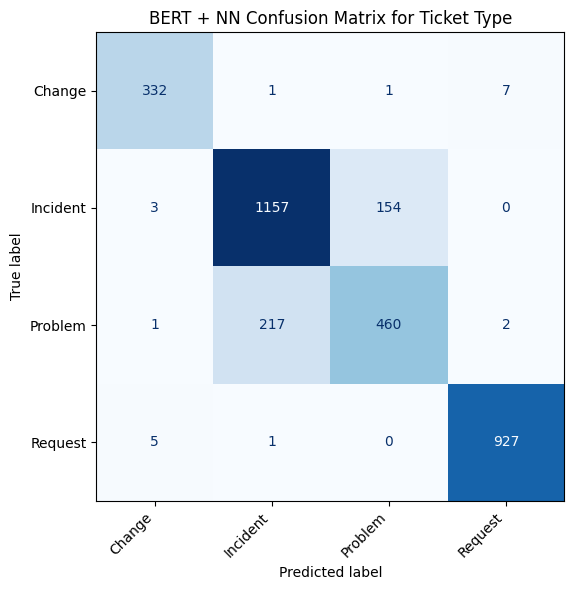

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


labels = sorted(y1_test.unique())
cm = confusion_matrix(y1_test, y1_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("Confusion matrix counts: rows=true labels, columns=predicted labels")
display(cm_df)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("BERT + NN Confusion Matrix for Ticket Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# NN (Predicting y2, Priority)

### Genetic Algorithm Tuning for Priority
- Replicate the y1 GA workflow for y2 priority labels
- Fitness selection strategy: macro F1 score, scoring="f1_macro", to treat high, medium, and low priority equally

In [7]:
from genetic_algorithm import build_pipeline, genetic_algorithm_search
from sklearn.metrics import classification_report, accuracy_score, f1_score


best_params_y2, best_cv_score_y2 = genetic_algorithm_search(X_train_y2, y2_train, scoring="f1_macro", population_size=8,
                                                            generations=5, cv_splits=3)

print("Best CV macro F1:", best_cv_score_y2)
print("Best parameters:", best_params_y2)

best_nn_y2 = build_pipeline(best_params_y2)
best_nn_y2.fit(X_train_y2, y2_train)
y2_pred = best_nn_y2.predict(X_test_y2)

print("Test accuracy:", accuracy_score(y2_test, y2_pred))
print("Test macro F1:", f1_score(y2_test, y2_pred, average="macro"))
print("Test weighted F1:", f1_score(y2_test, y2_pred, average="weighted"))
print(classification_report(y2_test, y2_pred))


Best CV macro F1: 0.6170650880201082
Best parameters: {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 0.04243414444194676, 'learning_rate_init': 0.0015268119529676472}
Test accuracy: 0.6915544675642595
Test macro F1: 0.6767868236932232
Test weighted F1: 0.6907519613559937
              precision    recall  f1-score   support

        high       0.74      0.74      0.74      1269
         low       0.63      0.58      0.60       675
      medium       0.68      0.70      0.69      1324

    accuracy                           0.69      3268
   macro avg       0.68      0.67      0.68      3268
weighted avg       0.69      0.69      0.69      3268



### Confusion Matrix for y2 Priority Predictions

Confusion matrix counts: rows=true labels, columns=predicted labels


,high,low,medium
high,939,79,251
low,94,389,192
medium,241,151,932


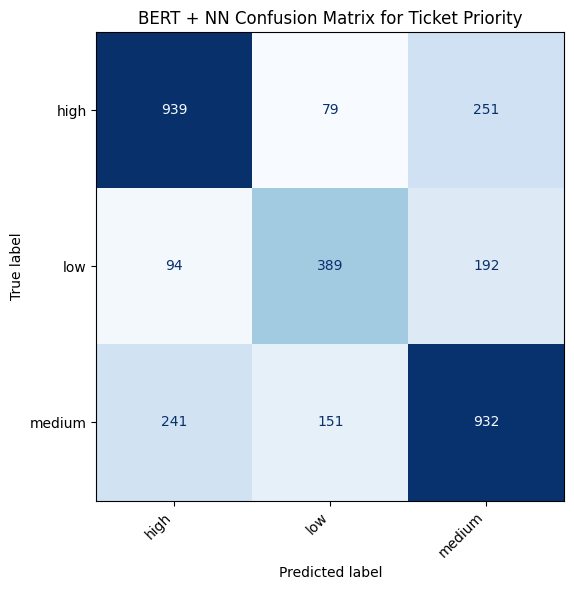

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


labels_y2 = sorted(y2_test.unique())
cm_y2 = confusion_matrix(y2_test, y2_pred, labels=labels_y2)
cm_y2_df = pd.DataFrame(cm_y2, index=labels_y2, columns=labels_y2)

print("Confusion matrix counts: rows=true labels, columns=predicted labels")
display(cm_y2_df)

disp_y2 = ConfusionMatrixDisplay(confusion_matrix=cm_y2, display_labels=labels_y2)
fig, ax = plt.subplots(figsize=(7, 6))
disp_y2.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("BERT + NN Confusion Matrix for Ticket Priority")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# NN (Predicting y3, Queue)

### Genetic Algorithm Tuning for Queue
- Replicate the same GA workflow for y3 queue labels
- Fitness selection strategy: macro F1 score, scoring="f1_macro"

In [9]:
from genetic_algorithm import build_pipeline, genetic_algorithm_search
from sklearn.metrics import classification_report, accuracy_score, f1_score


best_params_y3, best_cv_score_y3 = genetic_algorithm_search(X_train_y3, y3_train, scoring="f1_macro", population_size=8,
                                                            generations=5, cv_splits=3)

print("Best CV macro F1:", best_cv_score_y3)
print("Best parameters:", best_params_y3)

best_nn_y3 = build_pipeline(best_params_y3)
best_nn_y3.fit(X_train_y3, y3_train)
y3_pred = best_nn_y3.predict(X_test_y3)

print("Test accuracy:", accuracy_score(y3_test, y3_pred))
print("Test macro F1:", f1_score(y3_test, y3_pred, average="macro"))
print("Test weighted F1:", f1_score(y3_test, y3_pred, average="weighted"))
print(classification_report(y3_test, y3_pred))


Best CV macro F1: 0.5095421875456508
Best parameters: {'hidden_layer_sizes': (256, 128), 'activation': 'tanh', 'alpha': 0.00028654818140249656, 'learning_rate_init': 0.00042002461209626784}
Test accuracy: 0.5966952264381885
Test macro F1: 0.5716559443115374
Test weighted F1: 0.5954976029067814
                                 precision    recall  f1-score   support

           Billing and Payments       0.83      0.80      0.81       319
               Customer Service       0.54      0.55      0.55       482
                General Inquiry       0.62      0.45      0.52        47
                Human Resources       0.56      0.47      0.51        70
                     IT Support       0.51      0.49      0.50       388
                Product Support       0.56      0.60      0.58       615
          Returns and Exchanges       0.52      0.48      0.50       164
            Sales and Pre-Sales       0.57      0.38      0.46       103
Service Outages and Maintenance       0.69     

### Confusion Matrix for y3 Queue Predictions

Confusion matrix counts: rows=true labels, columns=predicted labels


,Billing and Payments,Customer Service,General Inquiry,Human Resources,IT Support,Product Support,Returns and Exchanges,Sales and Pre-Sales,Service Outages and Maintenance,Technical Support
Billing and Payments,254,15,0,2,11,13,7,2,0,15
Customer Service,17,265,3,0,39,54,7,4,8,85
General Inquiry,0,2,21,1,5,8,2,0,1,7
Human Resources,1,5,0,33,5,13,2,1,0,10
IT Support,3,35,4,2,189,37,7,3,5,103
Product Support,14,50,3,6,28,368,24,5,4,113
Returns and Exchanges,6,17,1,2,5,22,78,4,3,26
Sales and Pre-Sales,4,17,0,3,3,15,3,39,2,17
Service Outages and Maintenance,1,7,0,1,6,13,0,1,86,18
Technical Support,7,76,2,9,79,112,21,9,15,617


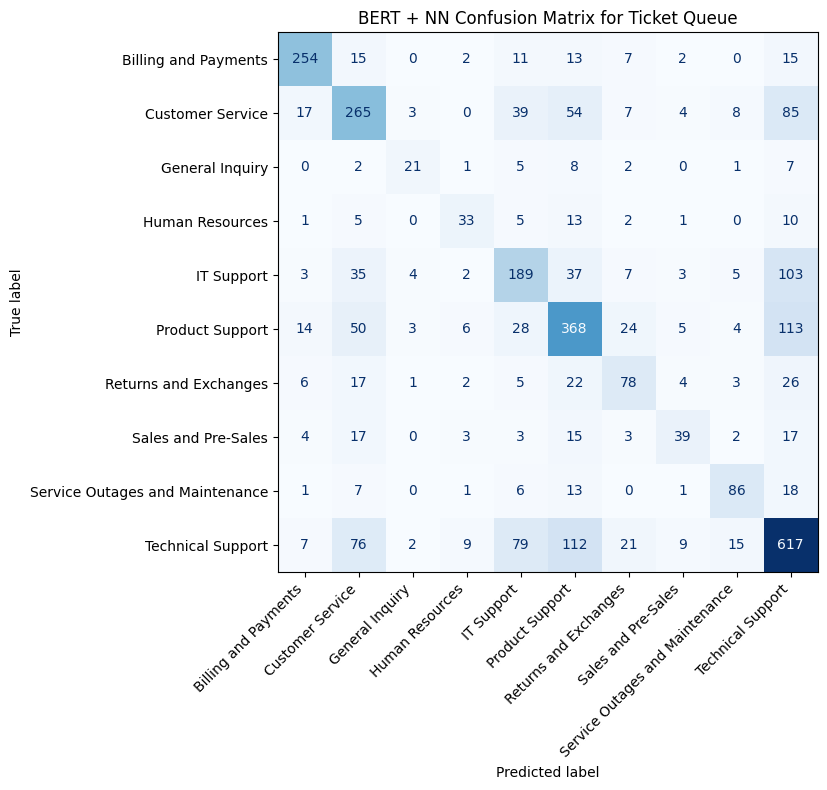

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


labels_y3 = sorted(y3_test.unique())
cm_y3 = confusion_matrix(y3_test, y3_pred, labels=labels_y3)
cm_y3_df = pd.DataFrame(cm_y3, index=labels_y3, columns=labels_y3)

print("Confusion matrix counts: rows=true labels, columns=predicted labels")
display(cm_y3_df)

disp_y3 = ConfusionMatrixDisplay(confusion_matrix=cm_y3, display_labels=labels_y3)
fig, ax = plt.subplots(figsize=(10, 8))
disp_y3.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("BERT + NN Confusion Matrix for Ticket Queue")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
